In [1]:
import pandas as pd
import numpy as np
import joblib
from sklearn.model_selection import train_test_split

from Funcoes_Shap import calculate_shap_values, plot_shap_values, analyze_shap_by_group, extract_shap_array

# Importar dicionários e listas do arquivo auxiliar reorganizado
from Dicionarios_Listas_Auxiliares import (
    nomes_descritivos,
    colunas_socioeconomicas,
    colunas_escolares,
    origens_tipo,
    origens_base,
    get_nome_descritivo,
    get_tipo_variavel,
    get_origem_variavel
)

#### 1. Ler base de dados

In [2]:
# Obter dados
df_enem = pd.read_pickle('Bases\\Finais\\enem_censo_2023_full.pkl')

In [3]:
# Definir variáveis alvo de forma mais simples
notas_alvo = ['NUM_NOTA_MT', 'NUM_NOTA_LC', 'NUM_NOTA_CN', 'NUM_NOTA_CH', 'NUM_NOTA_REDACAO']

# Separar em treino e teste
X = df_enem.drop(columns=notas_alvo)
y = df_enem[notas_alvo]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Ajuste de tipo para MLflow -> Converter colunas inteiras para float
X_train = X_train.astype({col: 'float' for col in X_train.select_dtypes('int').columns})
X_test = X_test.astype({col: 'float' for col in X_test.select_dtypes('int').columns})

# Obter colunas categóricas
categorical_features = X_train.select_dtypes(include=['category']).columns.tolist()

# Criar Eval Set para validação cruzada (15% do conjunto de treino)
X_train_final, X_eval, y_train_final, y_eval = train_test_split(
    X_train,
    y_train,
    test_size=0.15,
    random_state=42
)

#### 2. Carregar modelos

In [4]:
# Estrutura mais simples para armazenar modelos
modelos = {}

In [5]:
# Carregar modelos de forma mais direta
for nota in notas_alvo:
    with open(f'Modelos\\modelo_lgbm_bayes_censo_enem_{nota}.pkl', 'rb') as file:
        modelos[nota] = joblib.load(file)

#### 3. Verificação dos dados importados

Agora utilizamos o arquivo auxiliar reorganizado que contém todos os dicionários e listas de forma estruturada.

In [6]:
# Verificação rápida dos dados importados
print(f"Total de nomes descritivos disponíveis: {len(nomes_descritivos)}")
print(f"Total de variáveis socioeconômicas: {len(colunas_socioeconomicas)}")
print(f"Total de variáveis escolares: {len(colunas_escolares)}")
print(f"Total de origens mapeadas (tipo): {len(origens_tipo)}")
print(f"Total de origens mapeadas (base): {len(origens_base)}")

# Exemplo de uso das funções auxiliares
print(f"\nExemplo - Variável NUM_Q001:")
print(f"  Nome descritivo: {get_nome_descritivo('NUM_Q001')}")
print(f"  Tipo: {get_tipo_variavel('NUM_Q001')}")
print(f"  Origem: {get_origem_variavel('NUM_Q001')}")

Total de nomes descritivos disponíveis: 114
Total de variáveis socioeconômicas: 33
Total de variáveis escolares: 73
Total de origens mapeadas (tipo): 106
Total de origens mapeadas (base): 106

Exemplo - Variável NUM_Q001:
  Nome descritivo: Grau estudo pai
  Tipo: SOCIOECONOMICO
  Origem: ENEM


#### 4. Análise SHAP

In [7]:
# Estrutura mais simples para valores SHAP
shap_values_dict = {}

Calculando SHAP para: NUM_NOTA_MT


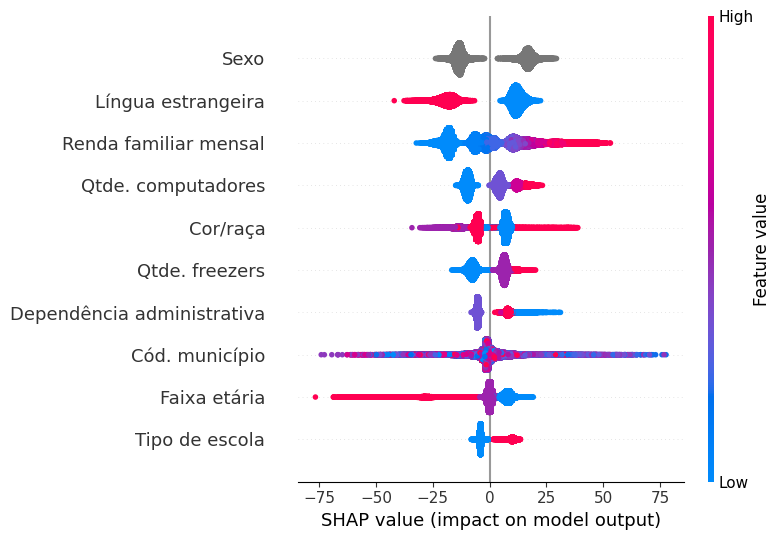

Calculando SHAP para: NUM_NOTA_LC


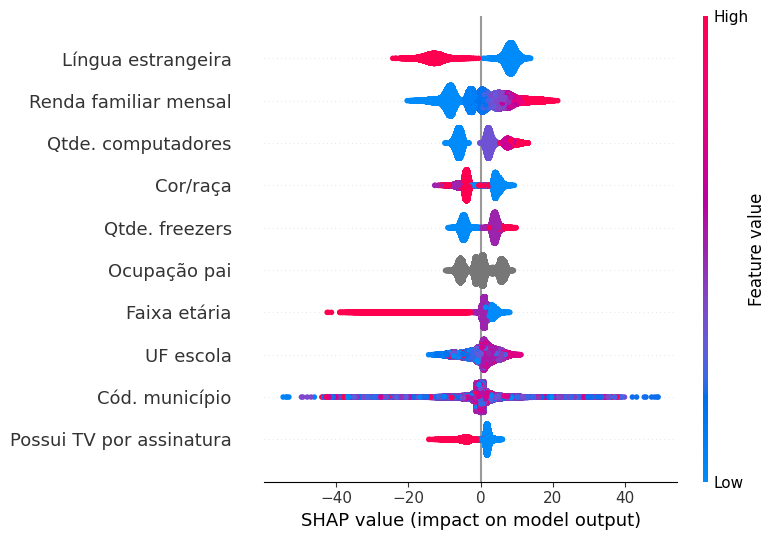

Calculando SHAP para: NUM_NOTA_CN


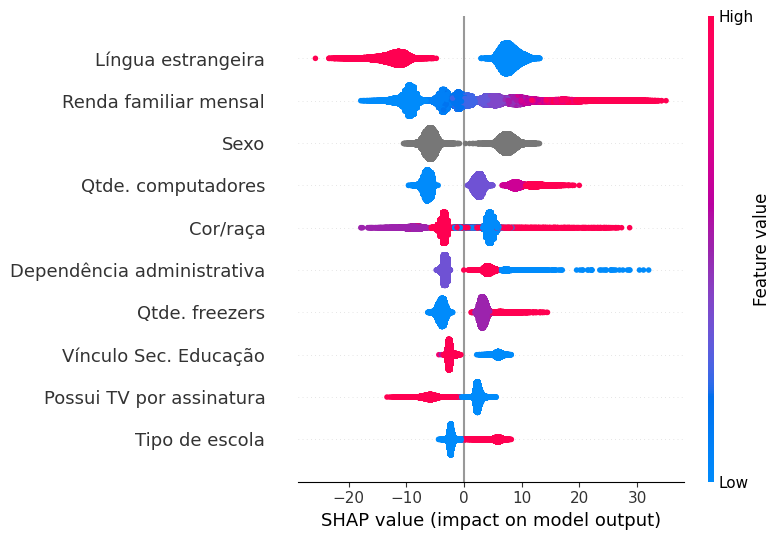

Calculando SHAP para: NUM_NOTA_CH


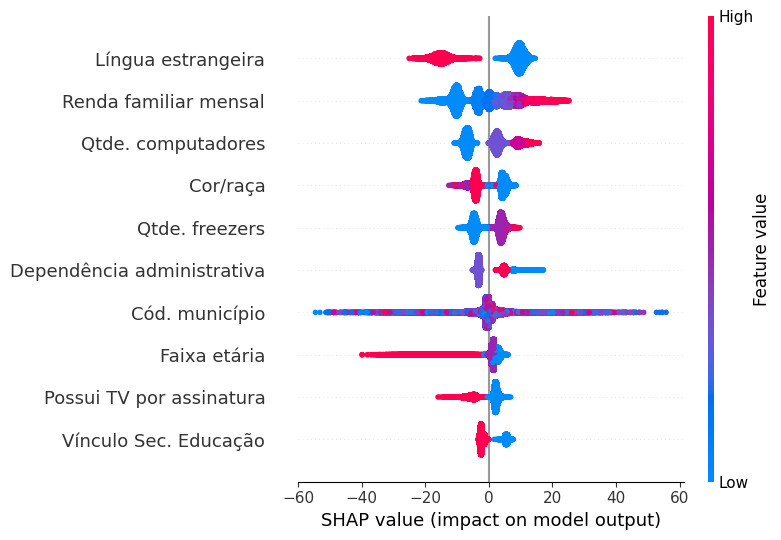

Calculando SHAP para: NUM_NOTA_REDACAO


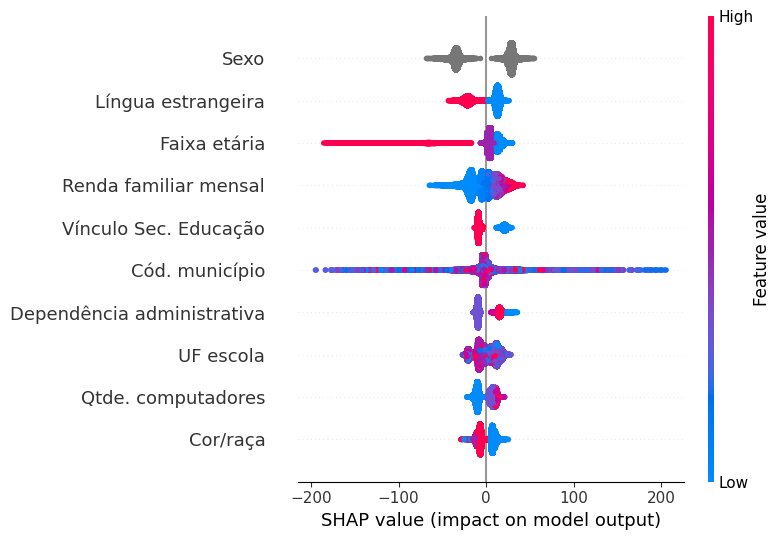

In [8]:
# Calcular valores SHAP para cada modelo de forma simplificada
for nota, modelo in modelos.items():
    print(f'Calculando SHAP para: {nota}')
    
    shap_values = calculate_shap_values(modelo, X_test)
    shap_values_dict[nota] = shap_values
    
    plot_shap_values(shap_values, X_test.columns, 10)

In [9]:
# Análise SHAP por origem (base de dados) - versão simplificada
for nota, shap_values in shap_values_dict.items():
    print(f'Analisando importância SHAP por origem para: {nota}')
    
    df_resultado = analyze_shap_by_group(shap_values, X_test.columns, get_origem_variavel, 'Origem')
    print(df_resultado)
    print()

Analisando importância SHAP por origem para: NUM_NOTA_MT
          Origem  SHAP_Importance  SHAP_Importance (%)
2           ENEM       121.975216            70.368681
1  CENSO ESCOLAR        33.743670            19.467049
0          AMBAS        17.618477            10.164269

Analisando importância SHAP por origem para: NUM_NOTA_LC
          Origem  SHAP_Importance  SHAP_Importance (%)
2           ENEM        65.809554            70.090199
1  CENSO ESCOLAR        19.946003            21.243410
0          AMBAS         8.137105             8.666391

Analisando importância SHAP por origem para: NUM_NOTA_CN
          Origem  SHAP_Importance  SHAP_Importance (%)
2           ENEM        70.977567            67.892282
1  CENSO ESCOLAR        23.678070            22.648821
0          AMBAS         9.888746             9.458898

Analisando importância SHAP por origem para: NUM_NOTA_CH
          Origem  SHAP_Importance  SHAP_Importance (%)
2           ENEM        70.198544            68.882026

In [10]:
# Análise SHAP por tipo (socioeconômico vs escolar) - versão simplificada
for nota, shap_values in shap_values_dict.items():
    print(f'Analisando importância SHAP por tipo para: {nota}')
    
    df_resultado = analyze_shap_by_group(shap_values, X_test.columns, get_tipo_variavel, 'Tipo')
    print(df_resultado)
    print()

Analisando importância SHAP por tipo para: NUM_NOTA_MT
             Tipo  SHAP_Importance  SHAP_Importance (%)
1  SOCIOECONOMICO       115.472133             66.61699
0       ESCOLARES        57.865230             33.38301

Analisando importância SHAP por tipo para: NUM_NOTA_LC
             Tipo  SHAP_Importance  SHAP_Importance (%)
1  SOCIOECONOMICO        63.946560            68.106026
0       ESCOLARES        29.946101            31.893974

Analisando importância SHAP por tipo para: NUM_NOTA_CN
             Tipo  SHAP_Importance  SHAP_Importance (%)
1  SOCIOECONOMICO        67.401093            64.471271
0       ESCOLARES        37.143290            35.528729

Analisando importância SHAP por tipo para: NUM_NOTA_CH
             Tipo  SHAP_Importance  SHAP_Importance (%)
1  SOCIOECONOMICO        67.351074            66.087958
0       ESCOLARES        34.560191            33.912042

Analisando importância SHAP por tipo para: NUM_NOTA_REDACAO
             Tipo  SHAP_Importance  SHAP_Imp

In [11]:
# Criar ranking SHAP de forma simplificada
rankings_shap = {}

for nota, shap_values in shap_values_dict.items():
    # Reutilizar função já criada para extrair array SHAP
    shap_array = extract_shap_array(shap_values)
    mean_abs_shap = np.abs(shap_array).mean(axis=0)
    
    # Criar ranking
    df_ranking = pd.DataFrame({
        'Feature': X_test.columns,
        'SHAP_Importance': mean_abs_shap
    })
    
    df_ranking = df_ranking.sort_values('SHAP_Importance', ascending=False).reset_index(drop=True)
    df_ranking['Posicao'] = df_ranking.index + 1
    
    rankings_shap[nota] = df_ranking.set_index('Feature')['Posicao'].to_dict()

print("Rankings SHAP calculados para todas as notas!")

Rankings SHAP calculados para todas as notas!


In [12]:
# Criar arquivo Excel de forma simplificada
todas_features = X_test.columns.tolist()

# DataFrame base com informações das variáveis
df_excel = pd.DataFrame({
    'Descrição': [get_nome_descritivo(feature) for feature in todas_features],
    'Tipo de Variável': [get_tipo_variavel(feature).replace('ESCOLARES', 'Escolar').replace('SOCIOECONOMICO', 'Socioeconômica') 
                        for feature in todas_features]
})

# Adicionar colunas de posição SHAP
for nota in notas_alvo:
    if nota in rankings_shap:
        df_excel[f'Posição SHAP {nota}'] = [rankings_shap[nota][feature] for feature in todas_features]

# Ordenar pelo ranking da primeira nota
df_excel = df_excel.sort_values(f'Posição SHAP {notas_alvo[0]}').reset_index(drop=True)

# Salvar arquivo
nome_arquivo = 'Referencia_Variaveis\\Importancia_Variaveis_Shap_Todas_Notas.xlsx'
df_excel.to_excel(nome_arquivo, index=False)

print(f"Arquivo Excel salvo em: {nome_arquivo}")
print(f"Dimensões: {df_excel.shape}")
print(f"Colunas: {list(df_excel.columns)}")
print(f"\nPrimeiras 10 variáveis (ordenadas por {notas_alvo[0]}):")
print(df_excel.head(10))

Arquivo Excel salvo em: Referencia_Variaveis\Importancia_Variaveis_Shap_Todas_Notas.xlsx
Dimensões: (106, 7)
Colunas: ['Descrição', 'Tipo de Variável', 'Posição SHAP NUM_NOTA_MT', 'Posição SHAP NUM_NOTA_LC', 'Posição SHAP NUM_NOTA_CN', 'Posição SHAP NUM_NOTA_CH', 'Posição SHAP NUM_NOTA_REDACAO']

Primeiras 10 variáveis (ordenadas por NUM_NOTA_MT):
                    Descrição Tipo de Variável  Posição SHAP NUM_NOTA_MT  \
0                        Sexo   Socioeconômica                         1   
1          Língua estrangeira   Socioeconômica                         2   
2       Renda familiar mensal   Socioeconômica                         3   
3          Qtde. computadores   Socioeconômica                         4   
4                    Cor/raça   Socioeconômica                         5   
5              Qtde. freezers   Socioeconômica                         6   
6  Dependência administrativa          Escolar                         7   
7              Cód. município          Esc